# Import Libraries

In [1]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Load data

In [6]:
uber_data = pd.read_csv("https://raw.githubusercontent.com/EshitaNandy/Uber-Trip-Analysis/master/My%20Uber%20Drives%20-%202016.csv")
uber_data.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [7]:
uber_data.columns

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')

In [8]:
uber_data.columns = ['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE']

uber_data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [9]:
uber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


# Data Pre-Processing

In [10]:
uber_data.isnull().sum()

,0
START_DATE,0
END_DATE,1
CATEGORY,1
START,1
STOP,1
MILES,0
PURPOSE,503


In [11]:
uber_data.PURPOSE.value_counts()

,count
PURPOSE,
Meeting,187
Meal/Entertain,160
Errand/Supplies,128
Customer Visit,101
Temporary Site,50
Between Offices,18
Moving,4
Airport/Travel,3
Commute,1


In [12]:
uber_data.PURPOSE.fillna('Not' , inplace=True)

In [13]:
uber_data.PURPOSE.value_counts()

,count
PURPOSE,
Not,503
Meeting,187
Meal/Entertain,160
Errand/Supplies,128
Customer Visit,101
Temporary Site,50
Between Offices,18
Moving,4
Airport/Travel,3


In [14]:
uber_data.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,Not


In [17]:
uber_data = uber_data[:-1]
uber_data.START_DATE = pd.to_datetime(uber_data.START_DATE)
uber_data.END_DATE = pd.to_datetime(uber_data.END_DATE)
uber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1154 entries, 0 to 1153
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[ns]
 1   END_DATE    1154 non-null   datetime64[ns]
 2   CATEGORY    1154 non-null   object        
 3   START       1154 non-null   object        
 4   STOP        1154 non-null   object        
 5   MILES       1154 non-null   float64       
 6   PURPOSE     1154 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.2+ KB


In [21]:
uber_data['date'] = pd.DatetimeIndex(uber_data.START_DATE).date
uber_data['time'] = pd.DatetimeIndex(uber_data.START_DATE).hour
uber_data['day-night'] = pd.cut(
    x= uber_data['time'],
    bins = [0,10,15,19,24],
    labels = ['Morning','Afternoon','Evening','Night']
)

uber_data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not,2016-01-02,1,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon


In [22]:
uber_data.dropna(inplace=True)


In [23]:
uber_data.drop_duplicates(inplace=True)

# Data Visualization

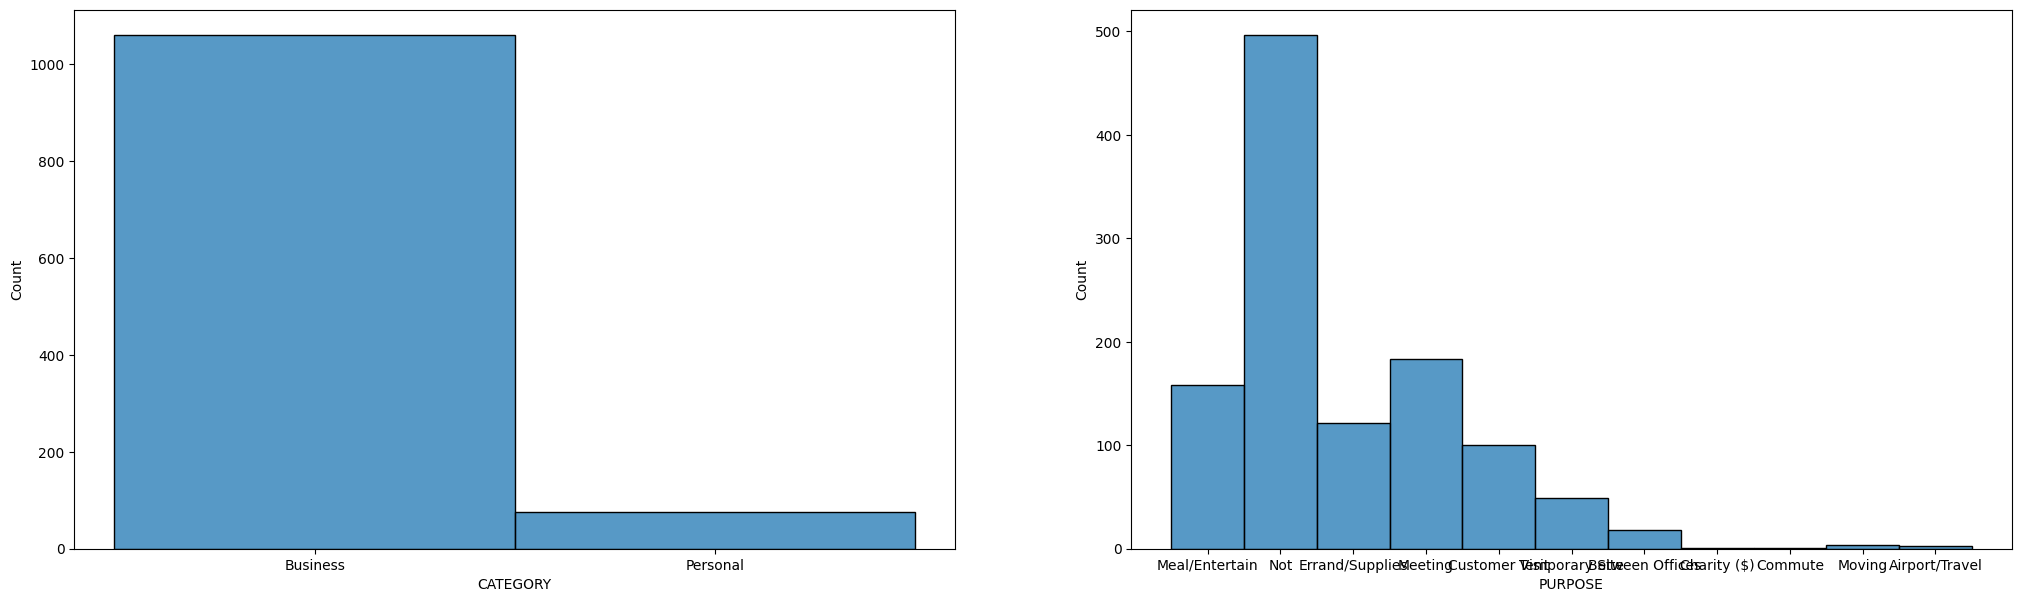

In [25]:
plt.figure(figsize=(25,7))
plt.subplot(1,2,1)
sns.histplot( uber_data['CATEGORY'])
plt.subplot(1,2,2)
sns.histplot( uber_data['PURPOSE'])
plt.show()

In [27]:
fig_cat = px.histogram( uber_data , x='CATEGORY' , title='Category Count(Plotly)')
fig_cat.show()
fig_pur = px.histogram( uber_data , x='PURPOSE' , title='Purpose Count(Plotly)')
fig_pur.show()

<Axes: xlabel='day-night', ylabel='Count'>

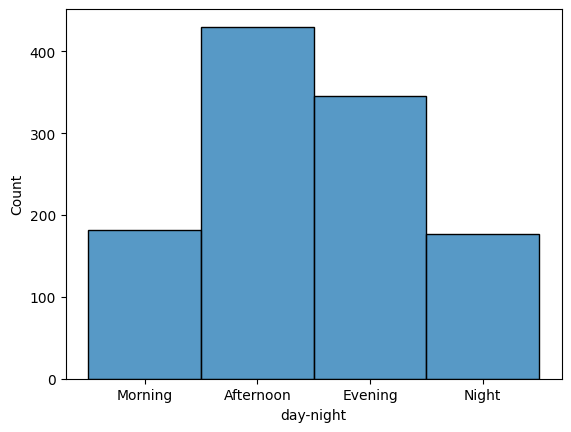

In [28]:
sns.histplot( uber_data['day-night'])

In [29]:
fig = px.histogram( uber_data ,
                   x='day-night' ,
                    )
fig.show()

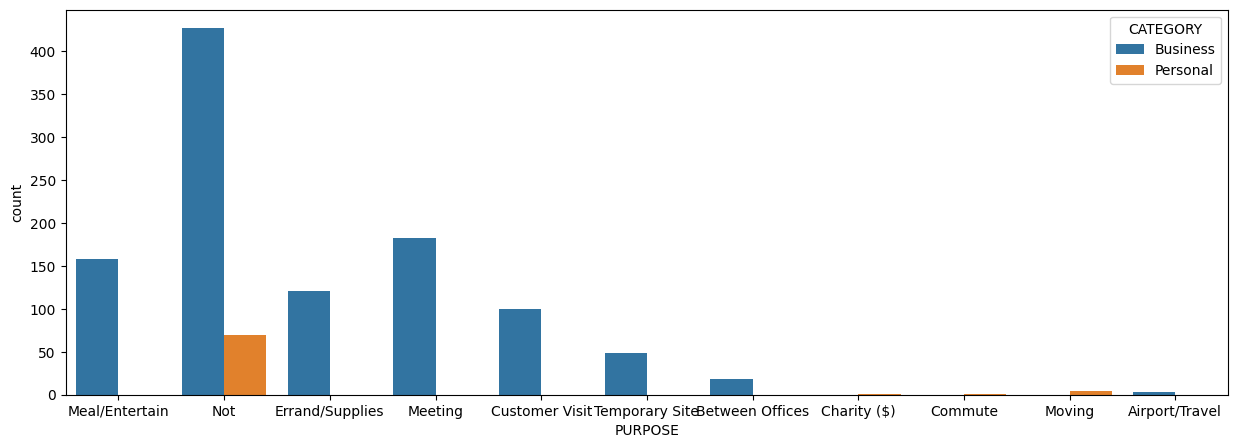

In [30]:
plt.figure(figsize=(15,5))
sns.countplot( uber_data , x='PURPOSE' , hue='CATEGORY')
plt.show()

In [32]:
fig = px.histogram(
    uber_data ,
    x='PURPOSE' ,
    color='CATEGORY',
    barmode='group',
    title='Purpose Count by category'
)
fig.show()



In [35]:
fig = px.histogram(
    uber_data ,
    x= 'PURPOSE' ,
    color='day-night',
    barmode='group',
    title= "Purpose Count by day-night"
)
fig.show()

In [38]:
from sklearn.preprocessing import OneHotEncoder
object_cols = ['CATEGORY', 'PURPOSE']
OH_encoder = OneHotEncoder(sparse_output=False)
OH_cols = pd.DataFrame(OH_encoder.fit_transform(uber_data[object_cols]))
OH_cols.index = uber_data.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = uber_data.drop(object_cols , axis=1)
uber_data = pd.concat([df_final , OH_cols] , axis=1)

In [39]:
uber_data

,START_DATE,END_DATE,START,STOP,MILES,date,time,day-night,CATEGORY_Business,CATEGORY_Personal,...,PURPOSE_Between Offices,PURPOSE_Charity ($),PURPOSE_Commute,PURPOSE_Customer Visit,PURPOSE_Errand/Supplies,PURPOSE_Meal/Entertain,PURPOSE_Meeting,PURPOSE_Moving,PURPOSE_Not,PURPOSE_Temporary Site
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Fort Pierce,Fort Pierce,5.1,2016-01-01,21,Night,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Fort Pierce,Fort Pierce,5.0,2016-01-02,1,Morning,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Fort Pierce,Fort Pierce,4.8,2016-01-02,20,Night,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Fort Pierce,Fort Pierce,4.7,2016-01-05,17,Evening,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Fort Pierce,West Palm Beach,63.7,2016-01-06,14,Afternoon,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-30 23:06:00,2016-12-30 23:10:00,Kar?chi,Kar?chi,0.8,2016-12-30,23,Night,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Kar?chi,Kar?chi,0.7,2016-12-31,1,Morning,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Kar?chi,Unknown Location,3.9,2016-12-31,13,Afternoon,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Unknown Location,Unknown Location,16.2,2016-12-31,15,Afternoon,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


['MILES', 'CATEGORY_Business', 'CATEGORY_Personal', 'PURPOSE_Airport/Travel', 'PURPOSE_Between Offices', 'PURPOSE_Charity ($)', 'PURPOSE_Commute', 'PURPOSE_Customer Visit', 'PURPOSE_Errand/Supplies', 'PURPOSE_Meal/Entertain', 'PURPOSE_Meeting', 'PURPOSE_Moving', 'PURPOSE_Not', 'PURPOSE_Temporary Site']


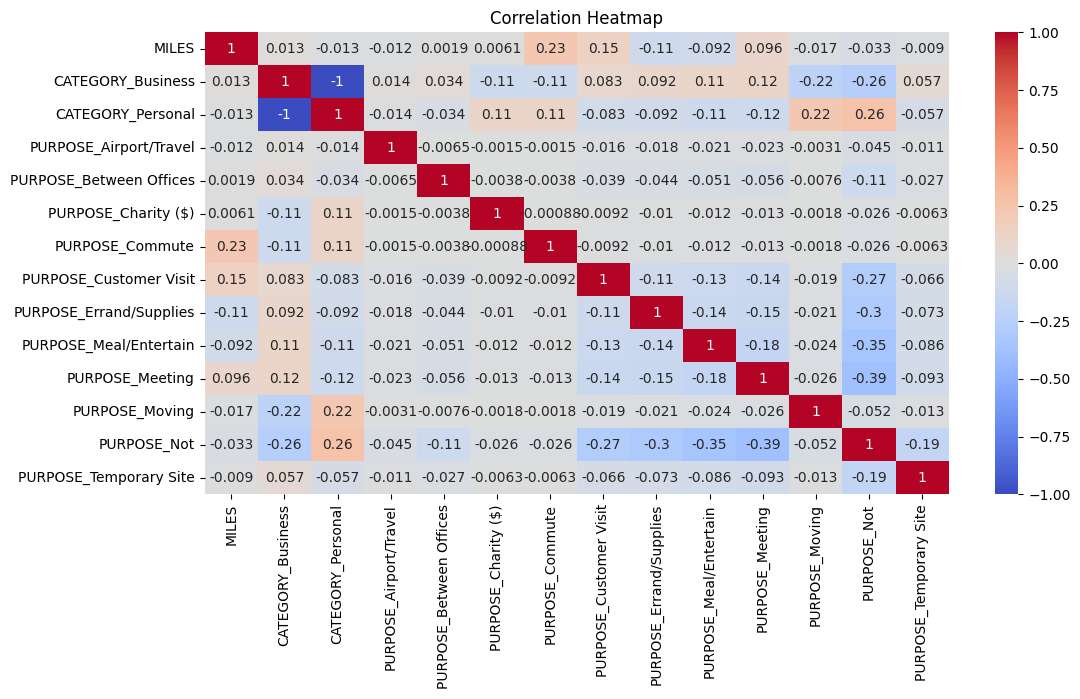

In [50]:
corr_cols = (uber_data.dtypes == 'float64').tolist()
corr_cols = uber_data.columns[corr_cols].tolist()
print(corr_cols)
df_corr = uber_data[corr_cols].corr()
plt.figure(figsize=(12, 6))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [52]:
corr = uber_data[corr_cols].corr()
fig = go.Figure(
    data=go.Heatmap(
    z=corr.values,
    x=corr.index.values,
    y=corr.columns.values,
    colorscale='BrBG',
    text=corr.round(2).values,
    texttemplate="%{text}"
))
fig.show()